# Multi-Video Analysis — 28 debates × 8 candidates

**Structure**
- **Part I — Audio-only**
- **Part II — Audio ↔ Visual** 
- **Part III — Multivideo findings** across all debates: candidate emotion
  profiles for all debates, poll correlation, opponent effect, joint dimensionality reduction.

## Setup

In [62]:
import sys, os
sys.path.insert(0, 'multivideo_analysis')
sys.path.insert(0, '../multivideo_analysis')
import os, sys, re, math, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, spearmanr, wilcoxon
from wordcloud import WordCloud

from pipelines import (build_labeled_audio, build_labels_all, build_seg_all,
                       CANDIDATES, NON_REDUNDANT, CAND_COLOR, extract_candidates)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
FEATURES_DIR = '../Project_Features'

In [63]:
# ----- Audio data -----
data = build_labeled_audio()
debate_videos = sorted(v for v in data['video'].unique() if 'vs' in v)

candidates_data = data[
    data['video'].isin(debate_videos) &
    data['speaker'].isin(CANDIDATES)
].copy()
candidates = CANDIDATES
color_map  = CAND_COLOR  

KEY_FEATURES = [
    'meanF0Hz','stdevF0Hz','HNR','localJitter','localShimmer',
    'speechrate','articulationrate','npause','asd','f1_mean','f2_mean','fdisp',
]

print(f'{len(data)} audio segments | {len(debate_videos)} debates')
print(f'Candidate segments: {len(candidates_data)}')

build_labeled_audio: 2656 segments | 28 debates | 9 unique speakers
2656 audio segments | 28 debates
Candidate segments: 2107


In [64]:
# ----- Silhouette quality scores —> needed for transcript cells later -----
quality_scores = {}
for v in debate_videos:
    E = np.stack(data[data['video'] == v]['speak_embeddings'].values)
    lbl = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(E)
    quality_scores[v] = silhouette_score(E, lbl, metric='cosine')
print(f'Silhouette scores computed for {len(quality_scores)} debates.')
print(f'Mean silhouette: {np.mean(list(quality_scores.values())):.3f}')

Silhouette scores computed for 28 debates.
Mean silhouette: 0.548


In [65]:
# ----- seg_all: visual pipeline required (slow first run, cached after) -----
SEG_ALL_CACHE = 'seg_all.pkl'
LABELS_CACHE  = 'labels_all.pkl'

if os.path.exists(SEG_ALL_CACHE):
    seg_all    = pd.read_pickle(SEG_ALL_CACHE)
    labels_all = pd.read_pickle(LABELS_CACHE) if os.path.exists(LABELS_CACHE) else None
    print(f'Loaded seg_all from cache: {seg_all.shape}')
else:
    print('Building labels_all (visual GMM pipeline, ~15 min)...')
    labels_all = build_labels_all(debate_videos, data)
    labels_all.to_pickle(LABELS_CACHE)
    print('Building seg_all (frame-audio join + aggregation)...')
    seg_all = build_seg_all(debate_videos, data, labels_all)
    seg_all.to_pickle(SEG_ALL_CACHE)
    print(f'seg_all saved: {seg_all.shape}')

emotion_cols      = [c for c in seg_all.columns if c.startswith('prob_')]
pose_feature_cols = ['shoulder_slope','body_openness','head_tilt','wrist_height','torso_height']
seg_cands = seg_all[seg_all['final_name'].isin(CANDIDATES)].copy()

print(f'seg_all shape: {seg_all.shape}')
print(f'Candidate segments in seg_all: {len(seg_cands)}')
print(f'Emotion cols: {emotion_cols}')
print(f'Pose cols: {pose_feature_cols}')

Building labels_all (visual GMM pipeline, ~15 min)...
  labeling Cotrim_Figueiredo_vs_Filipe_November_30 ...
  labeling Cotrim_Figueiredo_vs_Gouveia_Melo_November_20 ...
  labeling Cotrim_Figueiredo_vs_Marques_Mendes_December_7 ...
  labeling Cotrim_Figueiredo_vs_Ventura_December_19 ...
  labeling Filipe_vs_Gouveia_Melo_December_2 ...
  labeling Filipe_vs_Marques_Mendes_November_18 ...
  labeling Filipe_vs_Martins_December_10 ...
  labeling Filipe_vs_Pinto_December_8 ...
  labeling Gouveia_Melo_vs_Ventura_December_15 ...
  labeling Marques_Mendes_vs_Gouveia_Melo_December_21 ...
  labeling Martins_vs_Cotrim_Figueiredo_December_4 ...
  labeling Martins_vs_Gouveia_Melo_November_23 ...
  labeling Martins_vs_Marques_Mendes_December_12 ...
  labeling Martins_vs_Pinto_December_20 ...
  labeling Martins_vs_Ventura_November_28 ...
  labeling Pinto_vs_Cotrim_Figueiredo_November_24 ...
  labeling Pinto_vs_Gouveia_Melo_November_26 ...
  labeling Pinto_vs_Marques_Mendes_November_29 ...
  labeling S

---
# Part I — Audio-only multi-video analysis

These sections use only acoustic features and speaker embeddings (`data` from
`build_labeled_audio()`), without any visual information.

## I.A — Per-candidate acoustic profiles


Segments per candidate:
speaker
Marques_Mendes       336
Gouveia_Melo         330
Seguro               293
Cotrim_Figueiredo    281
Martins              260
Filipe               242
Ventura              195
Pinto                170



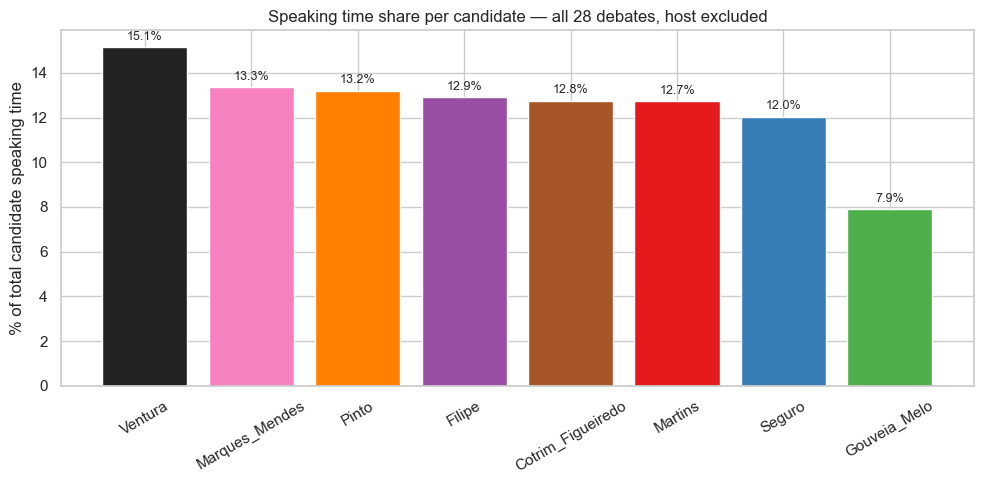

In [68]:
# Speaking time and segment counts
print('Segments per candidate:')
print(candidates_data['speaker'].value_counts().to_string())
print()
total_time_all = candidates_data['duration'].sum()
time_share = (candidates_data.groupby('speaker')['duration'].sum()
              / total_time_all * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(time_share.index, time_share.values,
              color=[color_map.get(c,'grey') for c in time_share.index], edgecolor='white')
for bar, val in zip(bars, time_share.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% of total candidate speaking time')
ax.set_title('Speaking time share per candidate — all 28 debates, host excluded', fontsize=12)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

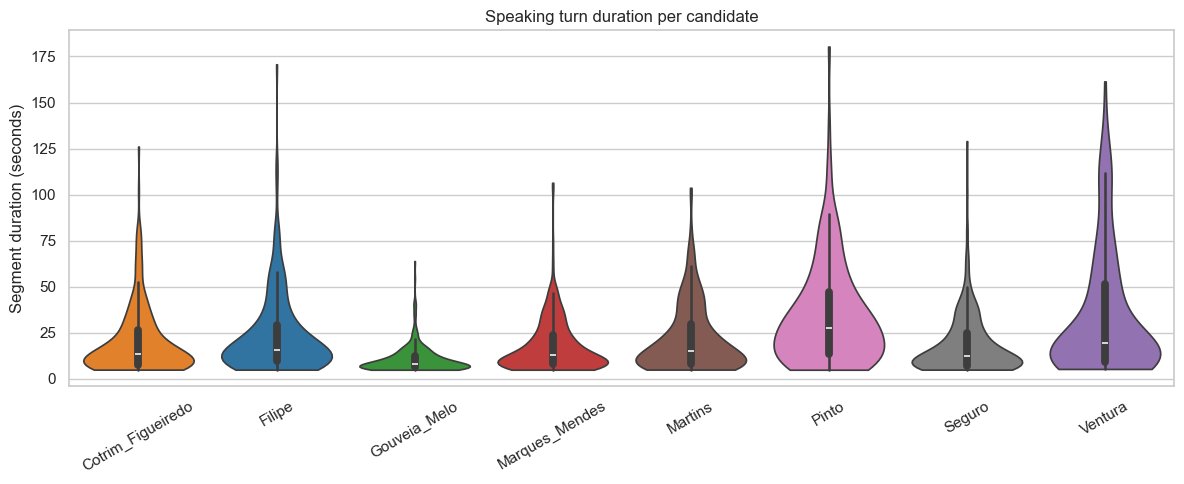

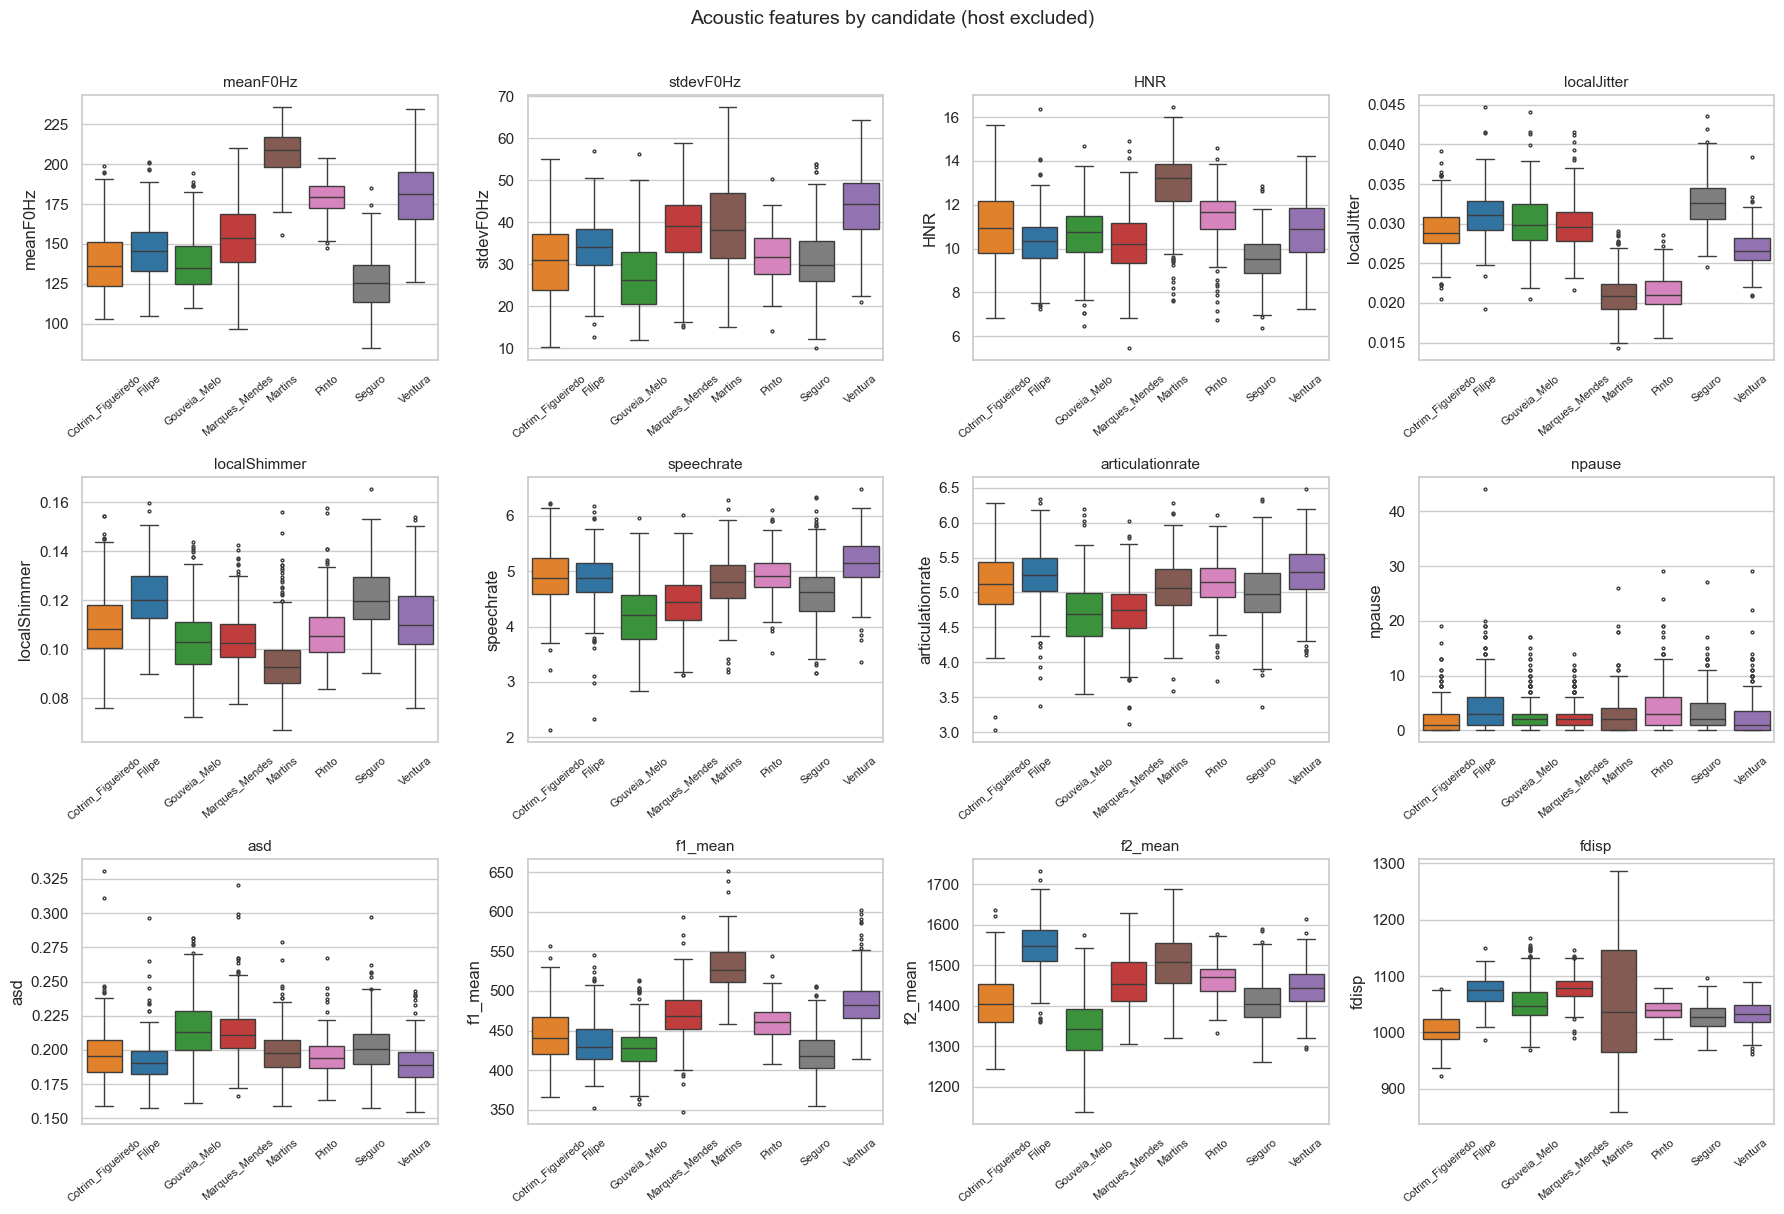

In [59]:
# Turn length distributions (violin) and box plots of KEY_FEATURES
fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(data=candidates_data, x='speaker', y='duration', hue="speaker",order=candidates, palette='tab10', ax=ax, cut=0, legend=False)
ax.set_xlabel(''); ax.set_ylabel('Segment duration (seconds)')
ax.set_title('Speaking turn duration per candidate', fontsize=12)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(3, 4, figsize=(18, 12)); axes = axes.flatten()
for i, col in enumerate(KEY_FEATURES):
    plot_data = candidates_data[['speaker', col]].dropna()
    sns.boxplot(data=plot_data, x='speaker', y=col, hue="speaker", ax=axes[i],palette='tab10', order=candidates, fliersize=2, legend=False)
    axes[i].set_title(col, fontsize=11); axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=40, labelsize=8)
plt.suptitle('Acoustic features by candidate (host excluded)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

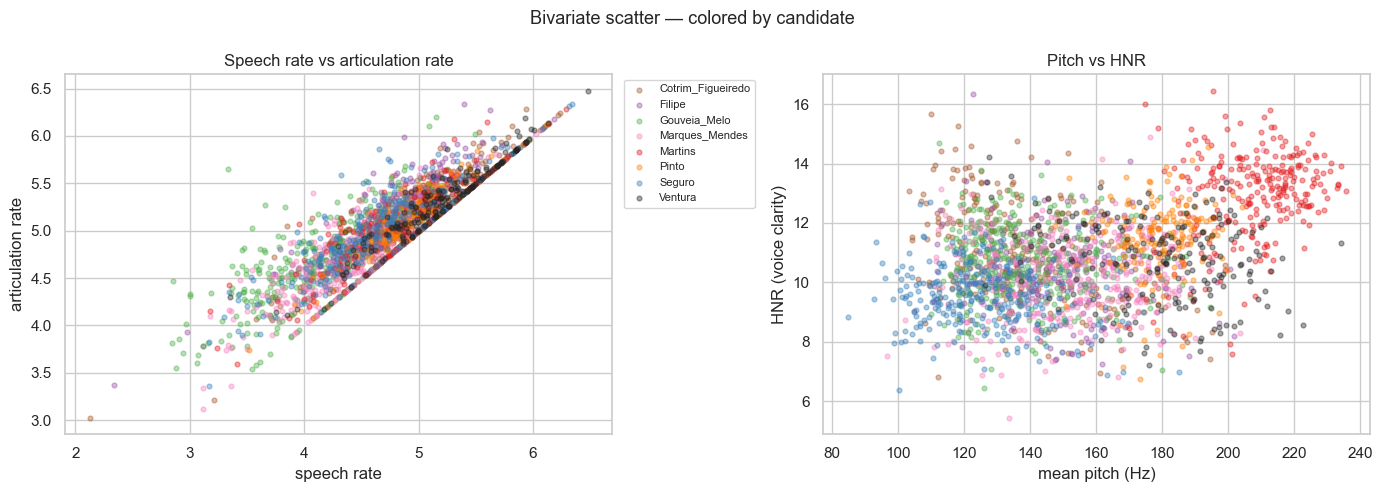

In [70]:
# Bivariate scatters: speech rate vs articulation, pitch vs HNR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cand in candidates:
    sub = candidates_data[candidates_data['speaker'] == cand]
    axes[0].scatter(sub['speechrate'], sub['articulationrate'],
                    alpha=0.4, s=12, label=cand, color=color_map.get(cand,'grey'))
    axes[1].scatter(sub['meanF0Hz'], sub['HNR'],
                    alpha=0.4, s=12, label=cand, color=color_map.get(cand,'grey'))
axes[0].set_xlabel('speech rate'); axes[0].set_ylabel('articulation rate')
axes[0].set_title('Speech rate vs articulation rate')
axes[0].legend(fontsize=8, bbox_to_anchor=(1.01,1), loc='upper left')
axes[1].set_xlabel('mean pitch (Hz)'); axes[1].set_ylabel('HNR (voice clarity)')
axes[1].set_title('Pitch vs HNR')
plt.suptitle('Bivariate scatter — colored by candidate', fontsize=13)
plt.tight_layout(); plt.show()

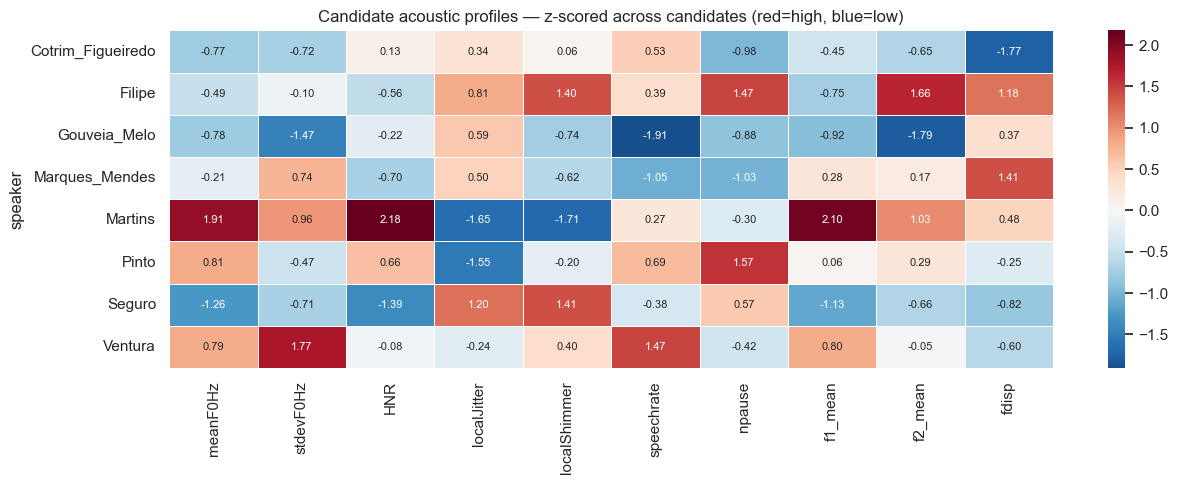

,meanF0Hz,stdevF0Hz,HNR,localJitter,localShimmer,speechrate,articulationrate,npause,asd,f1_mean,f2_mean,fdisp
speaker,,,,,,,,,,,,
Cotrim_Figueiredo,138.901,30.824,10.994,0.029,0.110,4.887,5.114,2.370,0.197,444.294,1409.672,1004.954
Filipe,146.061,33.927,10.335,0.031,0.121,4.845,5.221,4.260,0.193,434.131,1547.514,1072.432
Gouveia_Melo,138.577,27.107,10.657,0.030,0.103,4.188,4.703,2.452,0.215,428.329,1341.260,1054.000
Marques_Mendes,153.167,38.163,10.204,0.030,0.104,4.433,4.729,2.333,0.213,468.822,1458.663,1077.717
Martins,207.531,39.283,12.921,0.021,0.095,4.811,5.063,2.896,0.199,529.677,1509.766,1056.463
Pinto,179.363,32.092,11.487,0.021,0.108,4.931,5.143,4.335,0.195,461.455,1465.834,1039.732
Seguro,126.446,30.907,9.554,0.033,0.121,4.626,4.998,3.563,0.202,421.421,1409.298,1026.633
Ventura,178.980,43.306,10.791,0.027,0.113,5.154,5.287,2.800,0.190,486.098,1445.264,1031.651


In [71]:
# Normalized acoustic profile heatmap — who is high/low on each feature?
profile_nr = candidates_data.groupby('speaker')[NON_REDUNDANT].mean()
profile_norm = pd.DataFrame(
    StandardScaler().fit_transform(profile_nr),
    index=profile_nr.index, columns=profile_nr.columns
)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(profile_norm, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.4, annot_kws={'size': 8}, ax=ax)
ax.set_title('Candidate acoustic profiles — z-scored across candidates (red=high, blue=low)', fontsize=12)
plt.tight_layout(); plt.show()

# Mean values table
display(candidates_data.groupby('speaker')[KEY_FEATURES].mean().round(3))

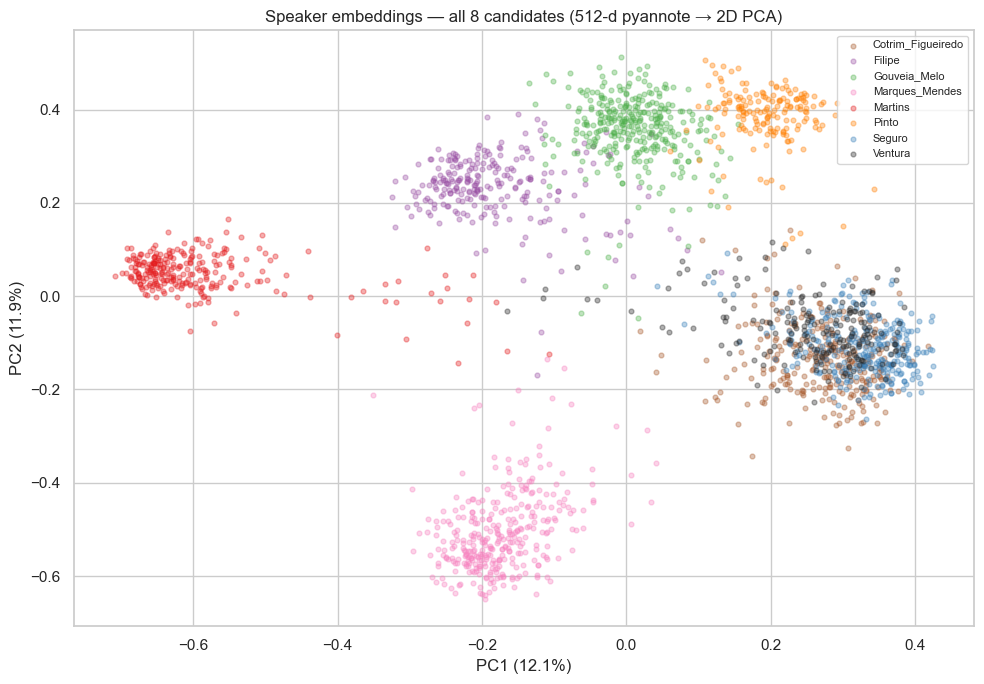

In [72]:
# PCA of speaker embeddings — do the 8 candidates separate in 512-d space?
emb_matrix = np.stack(candidates_data['speak_embeddings'].values)
pca_emb = PCA(n_components=2, random_state=42)
emb_2d  = pca_emb.fit_transform(emb_matrix)
v1, v2  = pca_emb.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))
for cand in candidates:
    mask = candidates_data['speaker'].values == cand
    ax.scatter(emb_2d[mask,0], emb_2d[mask,1],
               label=cand, alpha=0.35, s=12, color=color_map.get(cand,'grey'))
ax.set_title('Speaker embeddings — all 8 candidates (512-d pyannote → 2D PCA)', fontsize=12)
ax.set_xlabel(f'PC1 ({v1:.1f}%)'); ax.set_ylabel(f'PC2 ({v2:.1f}%)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## I.B — Transcript analysis across all debates

In [ ]:
speech_files = [f for f in os.listdir(FEATURES_DIR) if f.endswith('_speech.pkl')]
sdfs = []
for f in speech_files:
    df = pd.read_pickle(os.path.join(FEATURES_DIR, f))
    df['video'] = f.replace('_speech.pkl','')
    sdfs.append(df)
data_speech = pd.concat(sdfs, ignore_index=True)
data_speech['word_count']   = data_speech['transcript'].apply(lambda t: len(str(t).split()) if pd.notnull(t) else 0)
data_speech['words_per_sec'] = data_speech['word_count'] / data_speech['duration']

# Merge speaker labels
ts_col = 'timestamp' if 'timestamp' in data_speech.columns else 'time stamp'
speech_labeled = data_speech.merge(
    data[['video','time stamp','speaker','party']].rename(columns={'time stamp':ts_col}),
    on=['video',ts_col], how='left')

speech_debates = speech_labeled[speech_labeled['video'].isin(debate_videos)].copy()
print(f'Speech segments: {len(speech_debates)} | labeled: {speech_debates["speaker"].notna().sum()}')

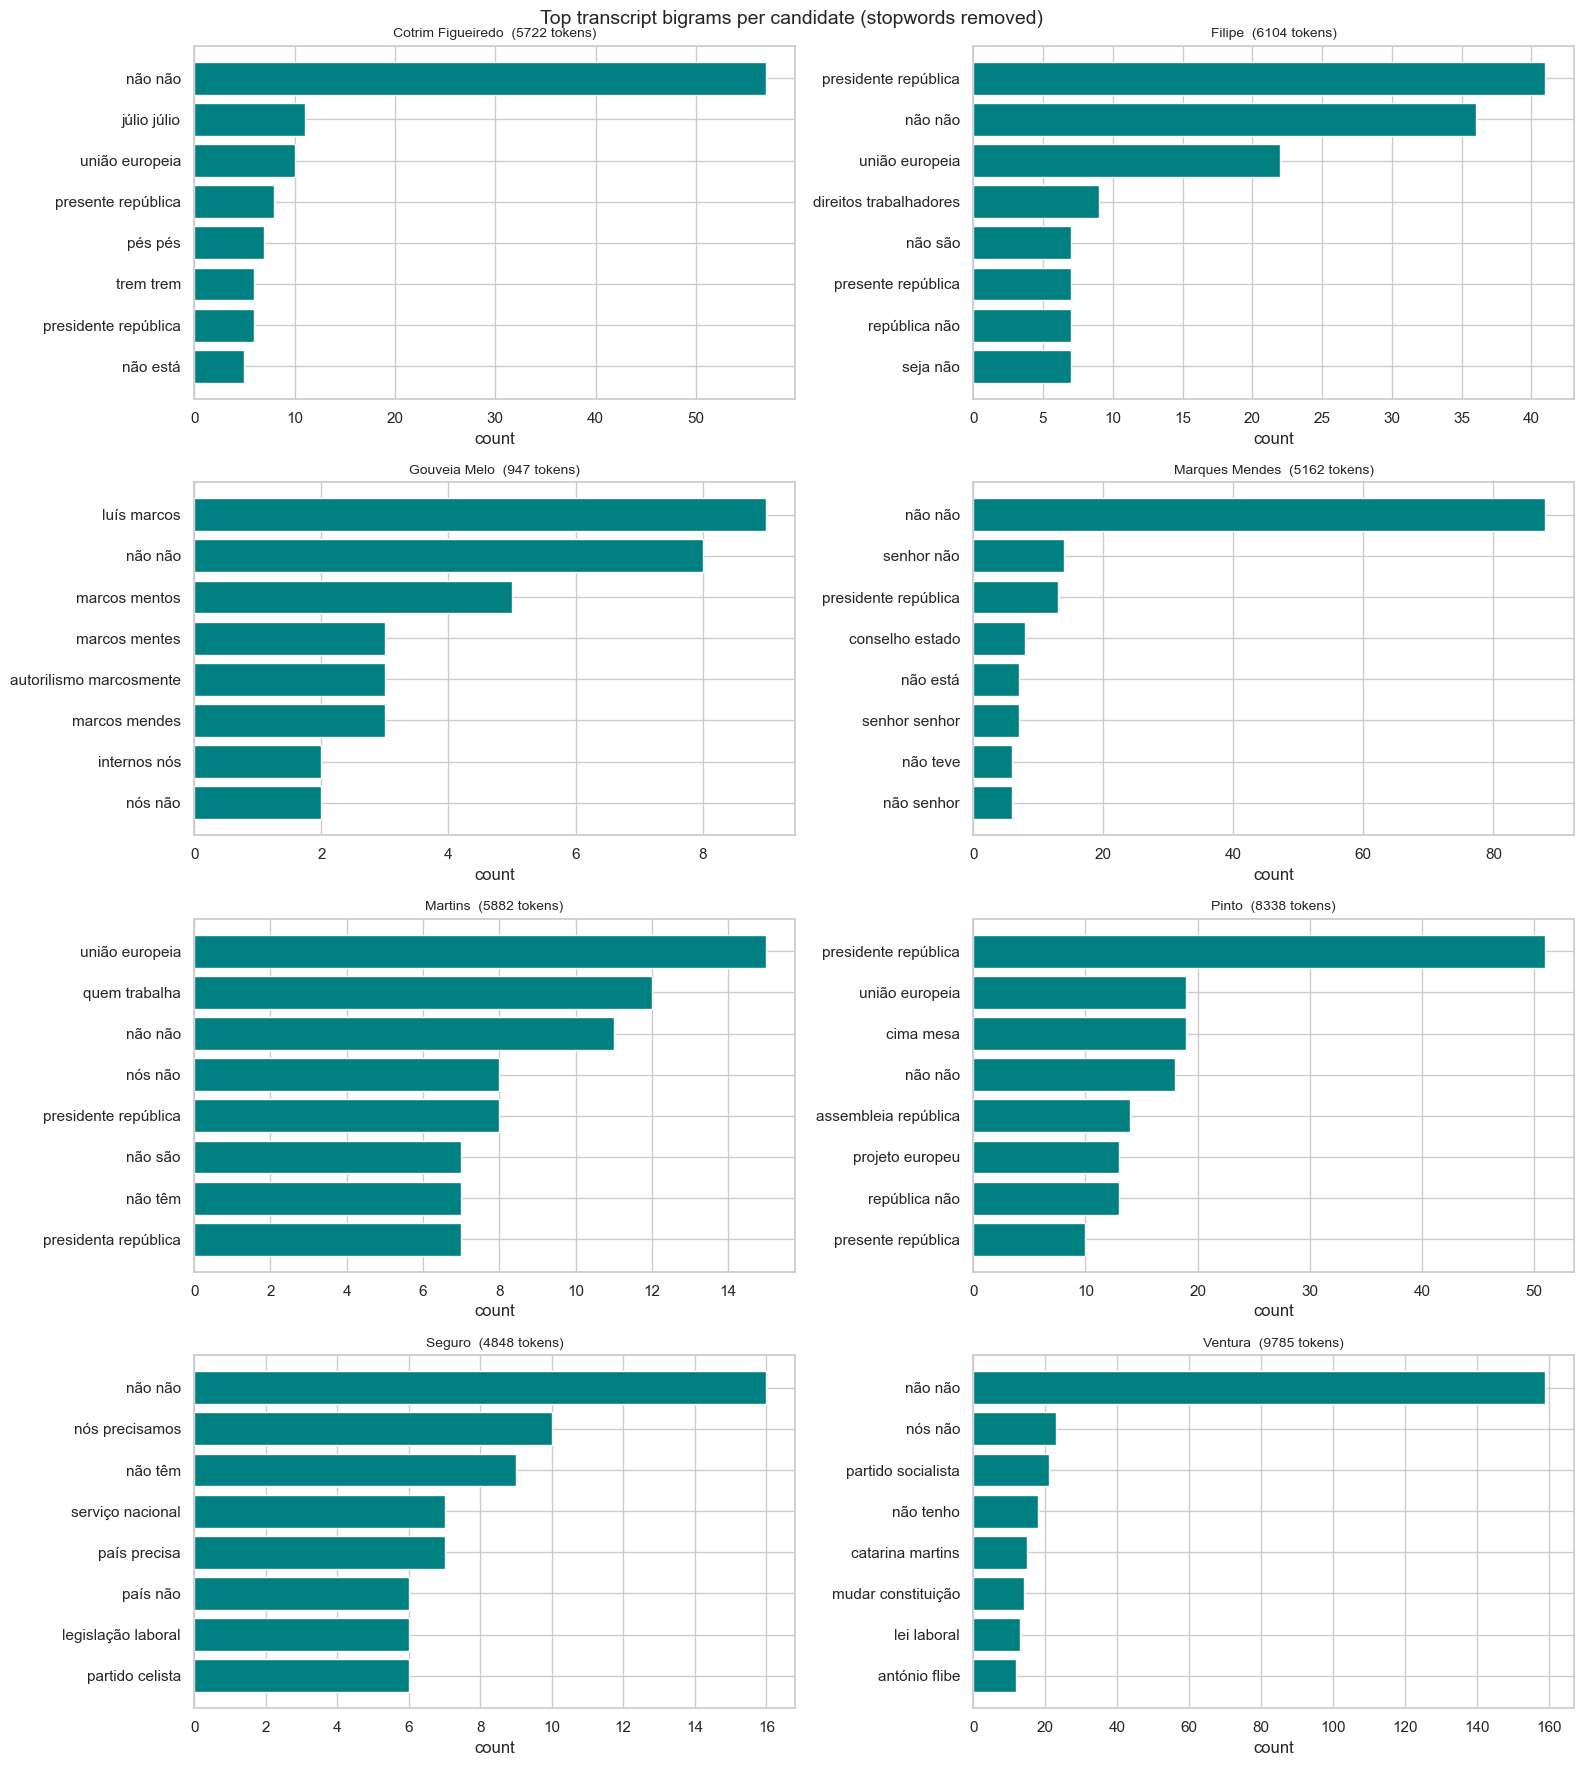

In [77]:
# Per-candidate bigrams
def tokenize(text, sw=PT_STOPWORDS, ml=3):
    tokens = re.findall(r'[a-zà-ÿ]+(?:-[a-zà-ÿ]+)?',
                        str(text).lower(), flags=re.IGNORECASE)
    return [t for t in tokens if len(t)>=ml and t not in sw]

candidate_text = speech_labeled[
    speech_labeled['video'].isin(debate_videos) &
    speech_labeled['speaker'].isin(CANDIDATES)
].copy()
candidate_text['tokens'] = candidate_text['transcript'].apply(tokenize)

fig, axes = plt.subplots(4, 2, figsize=(16, 18)); axes = axes.flatten()
for ax, cand in zip(axes, sorted(CANDIDATES)):
    sub = candidate_text[candidate_text['speaker']==cand]
    all_tokens = [t for toks in sub['tokens'] for t in toks]
    bigrams = Counter(zip(all_tokens, all_tokens[1:])).most_common(8)
    if not bigrams: ax.axis('off'); continue
    labels  = [' '.join(bg) for bg,_ in bigrams]
    counts  = [c for _,c in bigrams]
    ax.barh(labels[::-1], counts[::-1], color='teal', edgecolor='white')
    ax.set_title(f'{cand.replace("_"," ")}  ({len(all_tokens)} tokens)', fontsize=10)
    ax.set_xlabel('count')
for ax in axes[len(CANDIDATES):]: ax.axis('off')
plt.suptitle('Top transcript bigrams per candidate (stopwords removed)', fontsize=14)
plt.tight_layout(); plt.show()

### Segment-level UMAP

Instead of collapsing each candidate into a single average point, every transcript segment is plotted individually in UMAP space (cosine metric). Candidates that cluster separately are genuinely talking about different things.

c:\Users\dinis\Big Data\big_data_venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


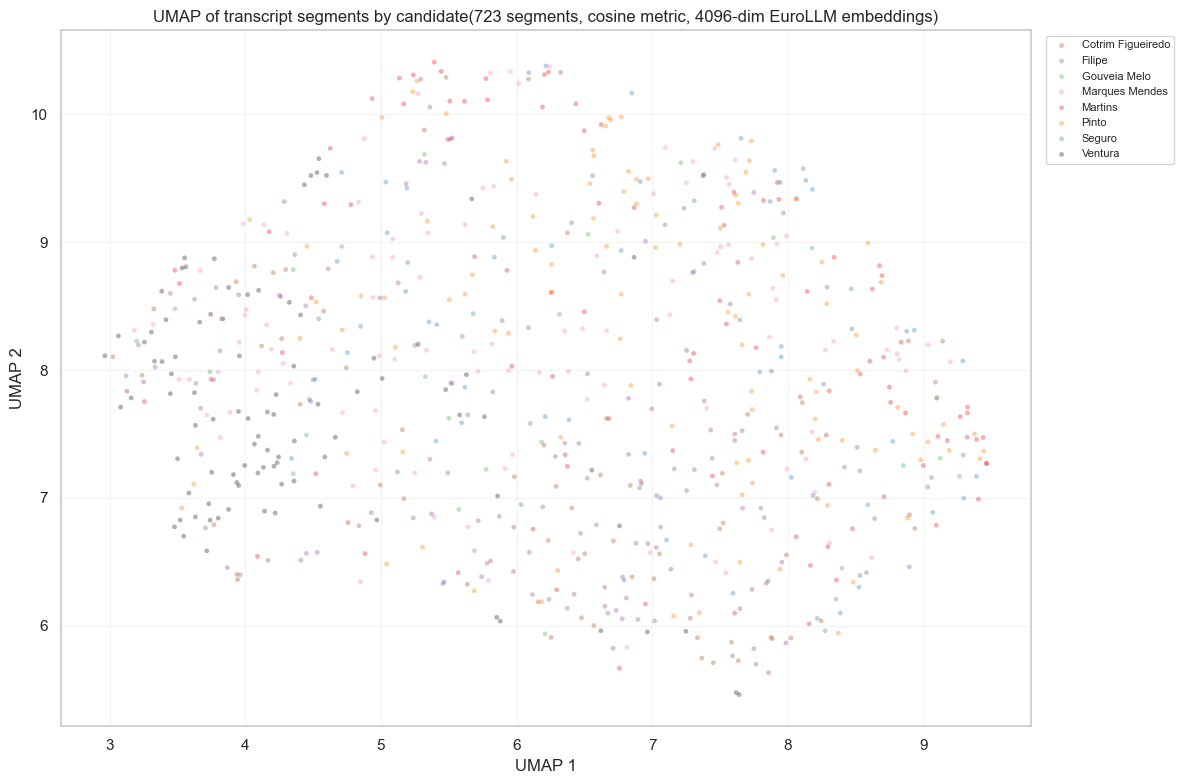

In [67]:
import umap as umap_lib

def _parse_emb(x):
    if isinstance(x, np.ndarray): return x
    return np.fromstring(str(x).strip('[]'), sep=' ')

speech_cands_emb = (speech_debates[speech_debates['speaker'].isin(CANDIDATES)]
                    .dropna(subset=['text_embedding'])
                    .copy())
speech_cands_emb['text_embedding'] = speech_cands_emb['text_embedding'].apply(_parse_emb)

E = np.stack(speech_cands_emb['text_embedding'].values)
speakers = speech_cands_emb['speaker'].values

# UMAP with cosine metric
reducer = umap_lib.UMAP(n_components=2, metric='cosine', random_state=42,
                         n_neighbors=30, min_dist=0.1)
E_2d = reducer.fit_transform(E)

fig, ax = plt.subplots(figsize=(12, 8))
for cand in CANDIDATES:
    mask = speakers == cand
    ax.scatter(E_2d[mask, 0], E_2d[mask, 1],
               c=CAND_COLOR.get(cand, '#888888'), label=cand.replace('_', ' '),
               alpha=0.35, s=12, edgecolors='none')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title(f'UMAP of transcript segments by candidate' f'({len(E)} segments, cosine metric, 4096-dim EuroLLM embeddings)',fontsize=12)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

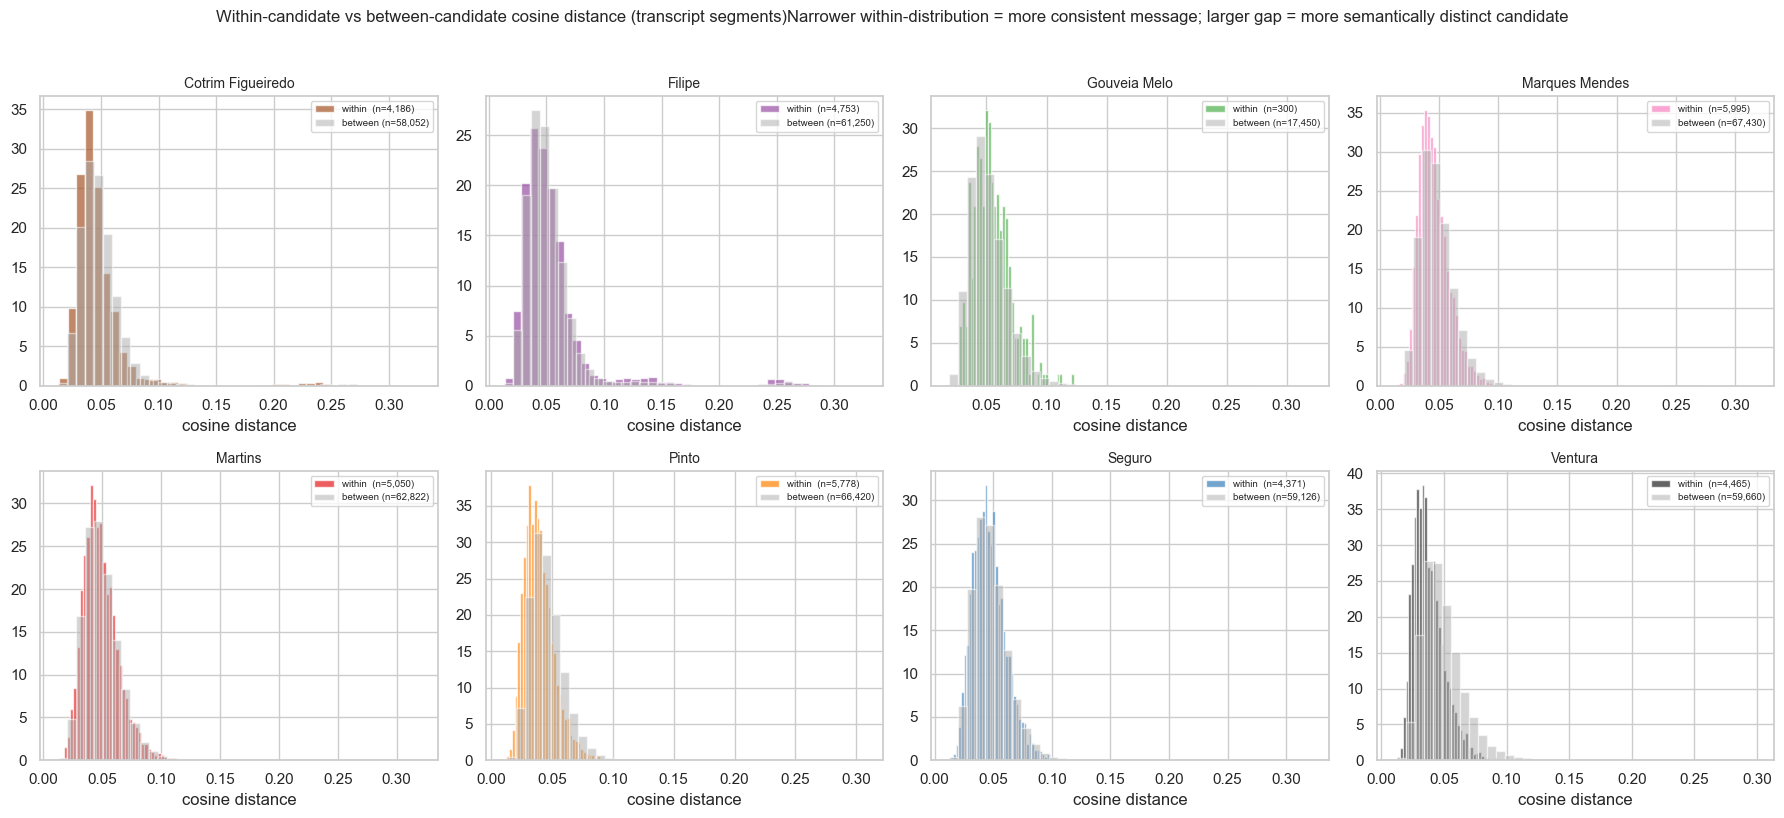

In [68]:
from scipy.spatial.distance import cdist

# Sample to keep computation tractable (max 150 segs per candidate)
rng = np.random.default_rng(42)
subsets = {}
for cand in CANDIDATES:
    idx = np.where(speakers == cand)[0]
    if len(idx) > 150:
        idx = rng.choice(idx, 150, replace=False)
    subsets[cand] = E[idx]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, cand in zip(axes, CANDIDATES):
    own  = subsets[cand]
    rest = np.vstack([v for c, v in subsets.items() if c != cand])

    within  = cdist(own,  own,  metric='cosine')[np.triu_indices(len(own),  k=1)]
    between = cdist(own,  rest, metric='cosine').ravel()

    ax.hist(within,  bins=40, alpha=0.7, color=CAND_COLOR.get(cand, '#888'),
            label=f'within  (n={len(within):,})',  density=True)
    ax.hist(between, bins=40, alpha=0.5, color='#aaaaaa',
            label=f'between (n={len(between):,})', density=True)
    ax.set_title(cand.replace('_', ' '), fontsize=10)
    ax.set_xlabel('cosine distance')
    ax.legend(fontsize=7)

for ax in axes[len(CANDIDATES):]: ax.axis('off')
plt.suptitle(
    'Within-candidate vs between-candidate cosine distance (transcript segments)'
    'Narrower within-distribution = more consistent message; '
    'larger gap = more semantically distinct candidate',
    fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

### Pairwise semantic distance between candidates

For every candidate pair: the median cosine distance across all their individual segment combinations. Avoids the centroid compression problem entirely. Lower = their transcripts overlap more topically.

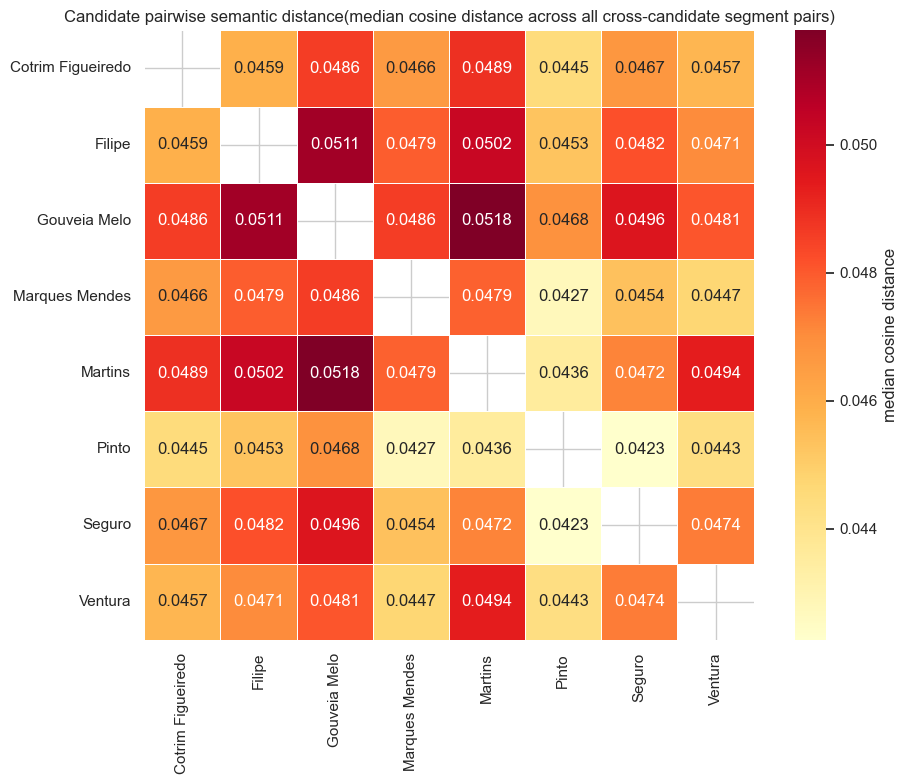

In [69]:
# 8x8 candidate median cosine distance — uses sampled subsets from previous cell
median_matrix = np.full((len(CANDIDATES), len(CANDIDATES)), np.nan)
for i, cA in enumerate(CANDIDATES):
    for j, cB in enumerate(CANDIDATES):
        if i == j: continue
        d = cdist(subsets[cA], subsets[cB], metric='cosine').ravel()
        median_matrix[i, j] = np.median(d)

labels_8 = [c.replace('_', ' ') for c in CANDIDATES]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pd.DataFrame(median_matrix, index=labels_8, columns=labels_8),
            annot=True, fmt='.4f', cmap='YlOrRd',
            mask=np.isnan(median_matrix), square=True, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'median cosine distance'})
ax.set_title('Candidate pairwise semantic distance' '(median cosine distance across all cross-candidate segment pairs)', fontsize=12)
plt.tight_layout(); plt.show()

### Message drift over the campaign

Did candidates stay on the same topics from November to January? Higher distance = more topic change between early and late campaign.

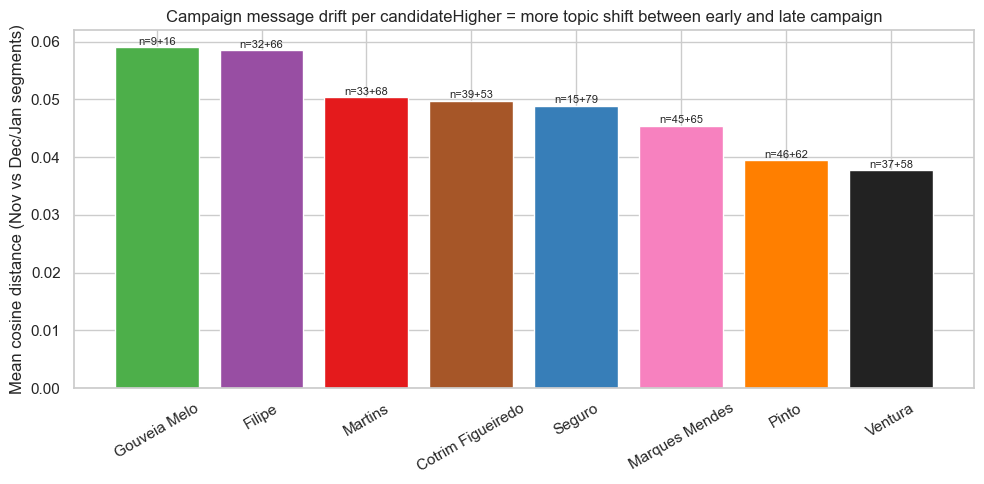

In [70]:
def _month(video):
    if 'November' in video: return 'Nov'
    if 'December' in video: return 'Dec'
    return 'Jan'

speech_cands_emb['month'] = speech_cands_emb['video'].apply(_month)

_rng = np.random.default_rng(42)
drift_rows = []
for cand in CANDIDATES:
    sub   = speech_cands_emb[speech_cands_emb['speaker'] == cand]
    early = np.stack(sub[sub['month'] == 'Nov']['text_embedding'].values)
    late  = np.stack(sub[sub['month'].isin(['Dec','Jan'])]['text_embedding'].values)
    if len(early) < 5 or len(late) < 5: continue
    if len(early) > 120: early = early[_rng.choice(len(early), 120, replace=False)]
    if len(late)  > 120: late  = late[_rng.choice(len(late),  120, replace=False)]
    drift_rows.append({'candidate': cand,
                       'drift': cdist(early, late, metric='cosine').mean(),
                       'n_early': len(early), 'n_late': len(late)})

drift_df = pd.DataFrame(drift_rows).sort_values('drift', ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [CAND_COLOR.get(c, '#888') for c in drift_df['candidate']]
bars = ax.bar(drift_df['candidate'].str.replace('_', ' '),
              drift_df['drift'], color=bar_colors, edgecolor='white')
for bar, row in zip(bars, drift_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f'n={row.n_early}+{row.n_late}', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Mean cosine distance (Nov vs Dec/Jan segments)')
ax.set_title('Campaign message drift per candidate''Higher = more topic shift between early and late campaign', fontsize=12)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

### Opponent influence on topic

Does who you're debating change what you talk about? For each candidate–opponent pair, this measures how far the candidate's speech drifts from their own baseline when facing that specific opponent.

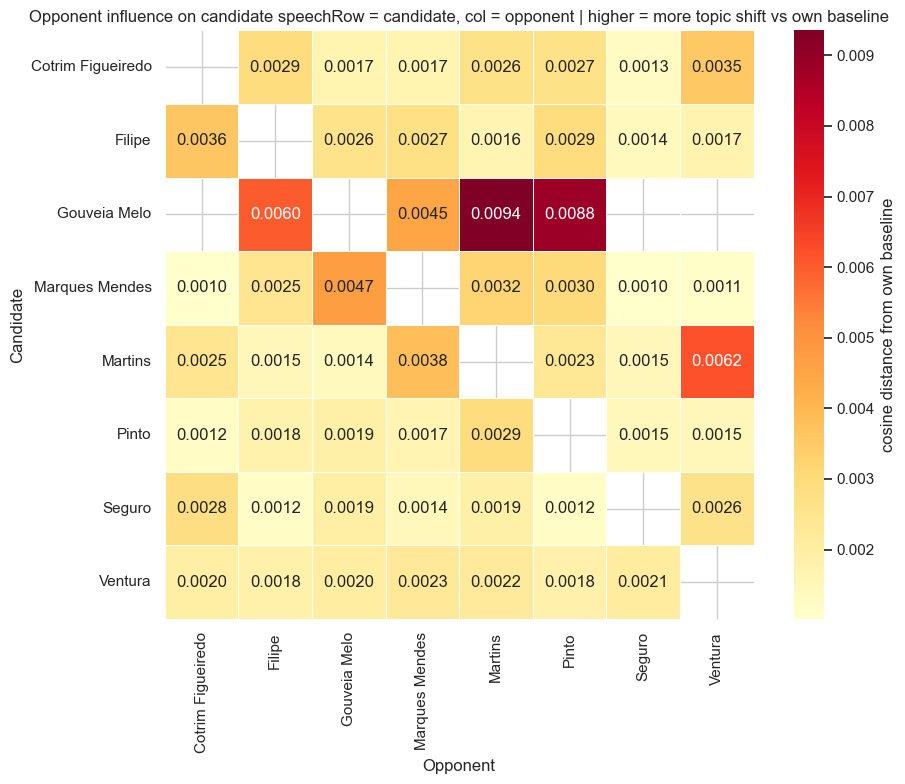

In [71]:
from scipy.spatial.distance import cosine as _cosine_d

def _get_opponent(video, candidate):
    for cA in CANDIDATES:
        if video.startswith(cA + '_vs_'):
            rest = video[len(cA)+4:]
            for cB in CANDIDATES:
                if rest.startswith(cB):
                    return cB if cA == candidate else (cA if cB == candidate else None)
    return None

speech_cands_emb['opponent'] = speech_cands_emb.apply(
    lambda r: _get_opponent(r['video'], r['speaker']), axis=1)

# overall mean embedding per candidate
overall_means = {
    cand: np.stack(speech_cands_emb[speech_cands_emb['speaker']==cand]['text_embedding'].values).mean(axis=0)
    for cand in CANDIDATES
}

inf_matrix = np.full((len(CANDIDATES), len(CANDIDATES)), np.nan)
for i, cand in enumerate(CANDIDATES):
    for j, opp in enumerate(CANDIDATES):
        if cand == opp: continue
        sub = speech_cands_emb[
            (speech_cands_emb['speaker']   == cand) &
            (speech_cands_emb['opponent']  == opp)]
        if len(sub) < 3: continue
        opp_mean = np.stack(sub['text_embedding'].values).mean(axis=0)
        inf_matrix[i, j] = _cosine_d(opp_mean, overall_means[cand])

labels_8 = [c.replace('_', ' ') for c in CANDIDATES]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pd.DataFrame(inf_matrix, index=labels_8, columns=labels_8),
            annot=True, fmt='.4f', cmap='YlOrRd',
            mask=np.isnan(inf_matrix), square=True, linewidths=0.4, ax=ax,
            cbar_kws={'label': 'cosine distance from own baseline'})
ax.set_title('Opponent influence on candidate speech''Row = candidate, col = opponent | higher = more topic shift vs own baseline',
             fontsize=12)
ax.set_xlabel('Opponent'); ax.set_ylabel('Candidate')
plt.tight_layout(); plt.show()

## I.C — Within-debate dynamics: arousal trajectory

Averaged across all 28 debates:

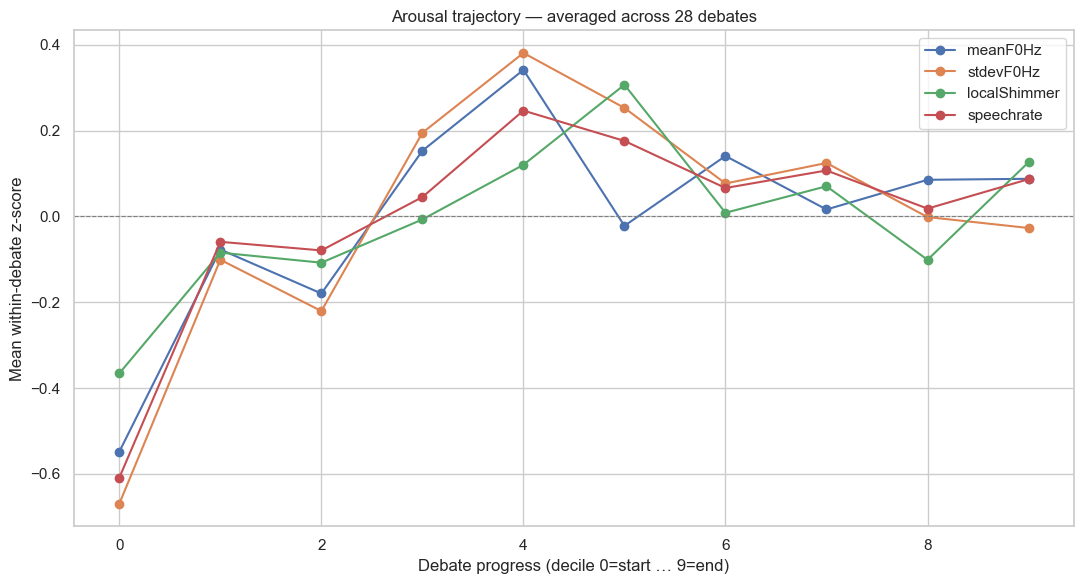

  meanF0Hz         r=+0.571  p=0.08  -> RISES
  stdevF0Hz        r=+0.482  p=0.16  -> RISES
  localShimmer     r=+0.553  p=0.10  -> RISES
  speechrate       r=+0.603  p=0.07  -> RISES


In [92]:
# Arousal trajectory — does debate intensity rise toward the end?
from scipy.stats import pearsonr

AROUSAL_FEATS = ['meanF0Hz','stdevF0Hz','localShimmer','speechrate']
N_BINS = 10

traj_rows = []
for v in debate_videos:
    sub = data[(data['video']==v) & (data['speaker'].isin(CANDIDATES))].copy()
    if len(sub) < N_BINS: continue
    sub = sub.sort_values('time stamp')
    t = sub['time stamp'].values.astype(float)
    sub['progress'] = (t-t.min())/(t.max()-t.min()+1e-9)
    for f in AROUSAL_FEATS:
        x = sub[f].values.astype(float); sd = x.std()
        sub[f+'_z'] = (x-x.mean())/sd if sd>0 else 0.0
    sub['bin'] = np.minimum((sub['progress']*N_BINS).astype(int), N_BINS-1)
    for _,r in sub.iterrows():
        for f in AROUSAL_FEATS: traj_rows.append({'video':v,'bin':r['bin'],'feature':f,'z':r[f+'_z']})

traj = pd.DataFrame(traj_rows)
pivot = traj.groupby(['bin','feature'])['z'].mean().unstack()[AROUSAL_FEATS]

fig, ax = plt.subplots(figsize=(11, 6))
for f in AROUSAL_FEATS: ax.plot(pivot.index, pivot[f], marker='o', label=f)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'Debate progress (decile 0=start … {N_BINS-1}=end)')
ax.set_ylabel('Mean within-debate z-score')
ax.set_title(f'Arousal trajectory — averaged across {traj["video"].nunique()} debates')
ax.legend(); plt.tight_layout(); plt.show()

for f in AROUSAL_FEATS:
    g = traj[traj['feature']==f].groupby('bin')['z'].mean()
    r,p = pearsonr(g.index.tolist(), g.values.tolist())
    print(f'  {f:16s} r={r:+.3f}  {"p<0.05" if p<0.05 else f"p={p:.2f}"}  -> {"RISES" if r>0 else "FALLS"}')

---
# Part II — Audio ↔ Visual correlations at multi-video scale

## II.1 Emotion ↔ Audio

                   screen_s  voice_s
Ventura               10878   6807.0
Gouveia_Melo          10133   3547.0
Seguro                 9693   5414.0
Filipe                 8886   5798.0
Pinto                  8655   5937.0
Marques_Mendes         8051   6001.0
Cotrim_Figueiredo      7899   5736.0
Martins                7727   5721.0


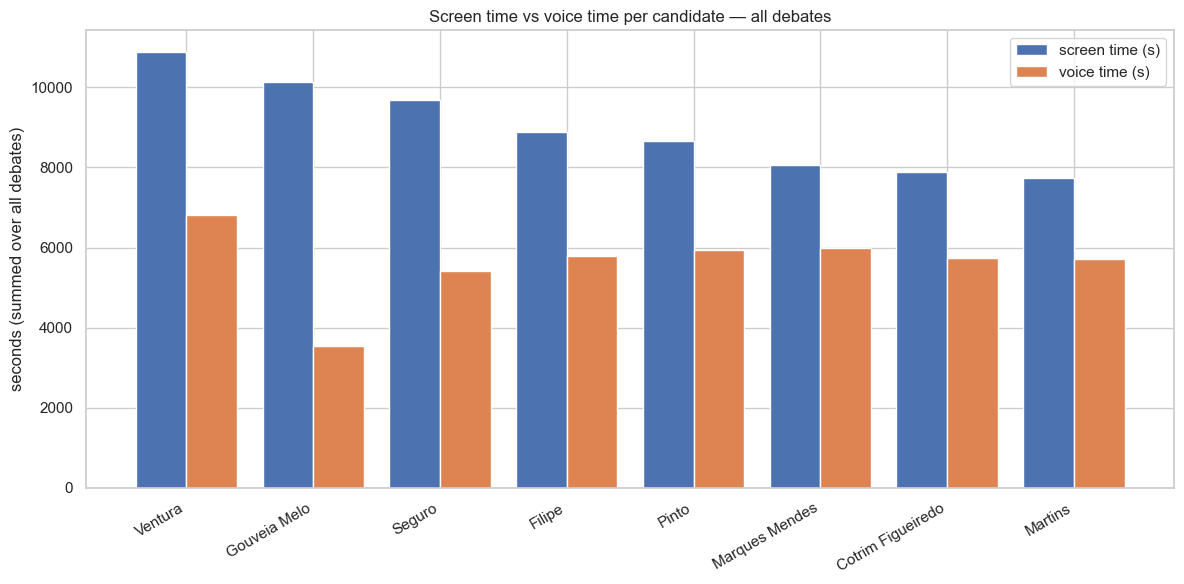

In [104]:
# SPEAKING VS SCREEN TIME
# screen time per candidate (seconds) across all debates = distinct (video, frame)
faces  = labels_all.dropna(subset=['final_name'])
faces  = faces[faces['final_name'].isin(CANDIDATES)]
screen = (faces.drop_duplicates(['final_name', 'Video_Name', 'Frame_Number'])
               .groupby('final_name').size())

# voice time per candidate (seconds) across all debates = sum of segment durations
voice  = (data[data['speaker'].isin(CANDIDATES)]
          .groupby('speaker')['duration'].sum())

comp = pd.DataFrame({'screen_s': screen, 'voice_s': voice}).reindex(CANDIDATES).fillna(0)
comp = comp.sort_values('screen_s', ascending=False)
print(comp.round(0))

x = np.arange(len(comp)); w = 0.4
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - w/2, comp['screen_s'], w, label='screen time (s)', color='#4C72B0')
ax.bar(x + w/2, comp['voice_s'],  w, label='voice time (s)',  color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ') for c in comp.index], rotation=30, ha='right')
ax.set_ylabel('seconds (summed over all debates)')
ax.set_title('Screen time vs voice time per candidate — all debates')
ax.legend()
plt.tight_layout()
plt.show()


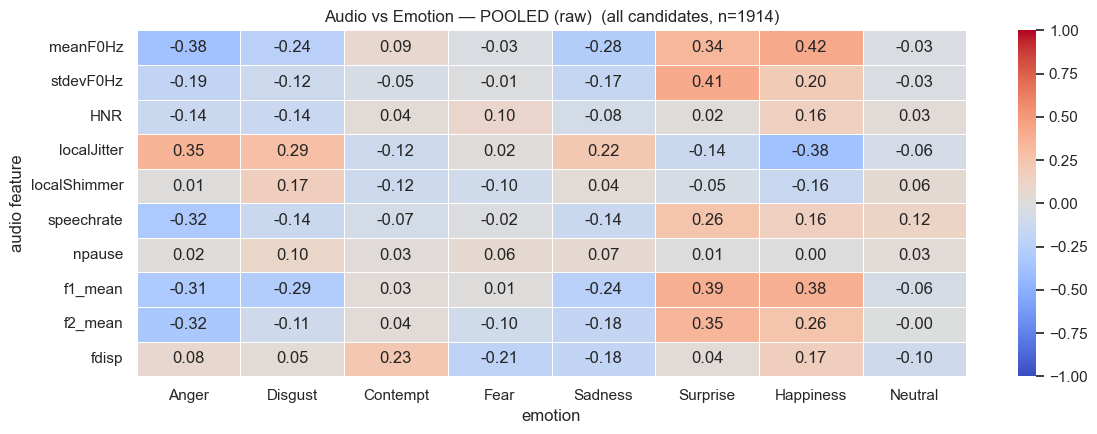

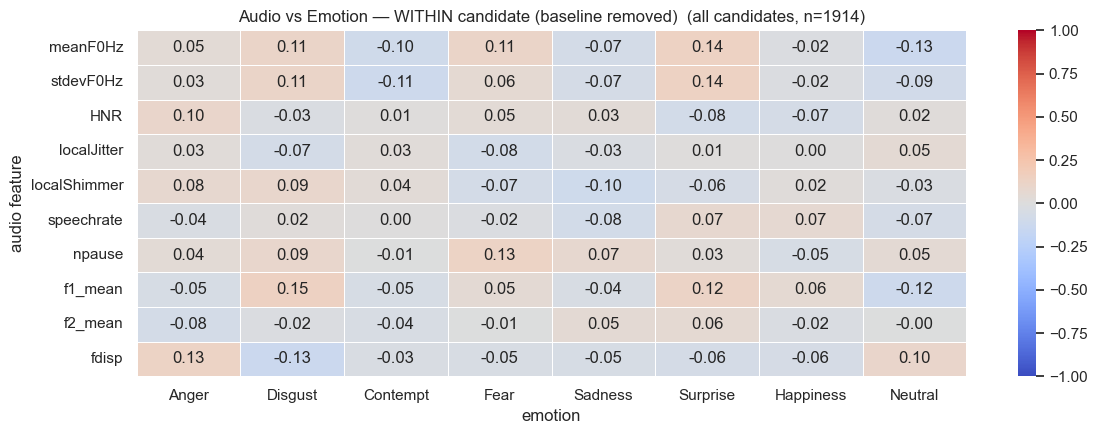

In [94]:
emotion_order = ['Anger','Disgust','Contempt','Fear','Sadness','Surprise','Happiness','Neutral']
ordered_prob  = [f'prob_{e}' for e in emotion_order]

pooled = seg_cands[NON_REDUNDANT + ordered_prob].corr('spearman').loc[NON_REDUNDANT, ordered_prob]

cen = seg_cands.copy()
for col in NON_REDUNDANT + ordered_prob:
    cen[col] = seg_cands[col] - seg_cands.groupby('final_name')[col].transform('mean')
within = cen[NON_REDUNDANT + ordered_prob].corr('spearman').loc[NON_REDUNDANT, ordered_prob]

for mat, ttl in [(pooled, 'POOLED (raw)'), (within, 'WITHIN candidate (baseline removed)')]:
    mat.columns = emotion_order
    plt.figure(figsize=(12, 4.5))
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=.5)
    plt.title(f'Audio vs Emotion — {ttl}  (all candidates, n={len(seg_cands)})')
    plt.xlabel('emotion'); plt.ylabel('audio feature')
    plt.tight_layout(); plt.show()

## II.2 Poses ↔ Audio

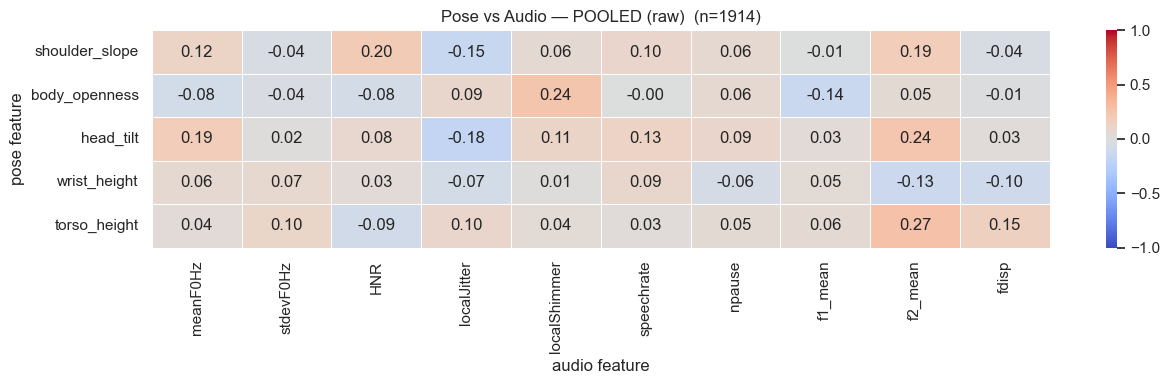

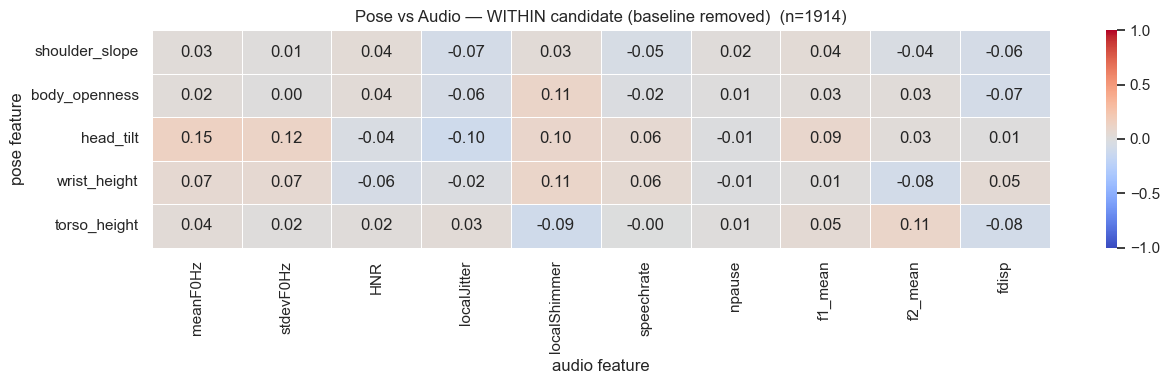

In [95]:
vp = seg_cands.dropna(subset=pose_feature_cols)
pooled = vp[pose_feature_cols + NON_REDUNDANT].corr('spearman').loc[pose_feature_cols, NON_REDUNDANT]

cen = vp.copy()
for col in pose_feature_cols + NON_REDUNDANT:
    cen[col] = vp[col] - vp.groupby('final_name')[col].transform('mean')
within = cen[pose_feature_cols + NON_REDUNDANT].corr('spearman').loc[pose_feature_cols, NON_REDUNDANT]

for mat, ttl in [(pooled, 'POOLED (raw)'), (within, 'WITHIN candidate (baseline removed)')]:
    plt.figure(figsize=(13, 4))
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=.5)
    plt.title(f'Pose vs Audio — {ttl}  (n={len(vp)})')
    plt.xlabel('audio feature'); plt.ylabel('pose feature')
    plt.tight_layout(); plt.show()

---
# Part III — Extra Multivideo findings

## III.1 — Per-candidate emotion profile

Who is consistently **angry, surprised, sad** across all their debates?
For each candidate we compute their mean emotion probability profile (averaged over
all segments from all their debates). 

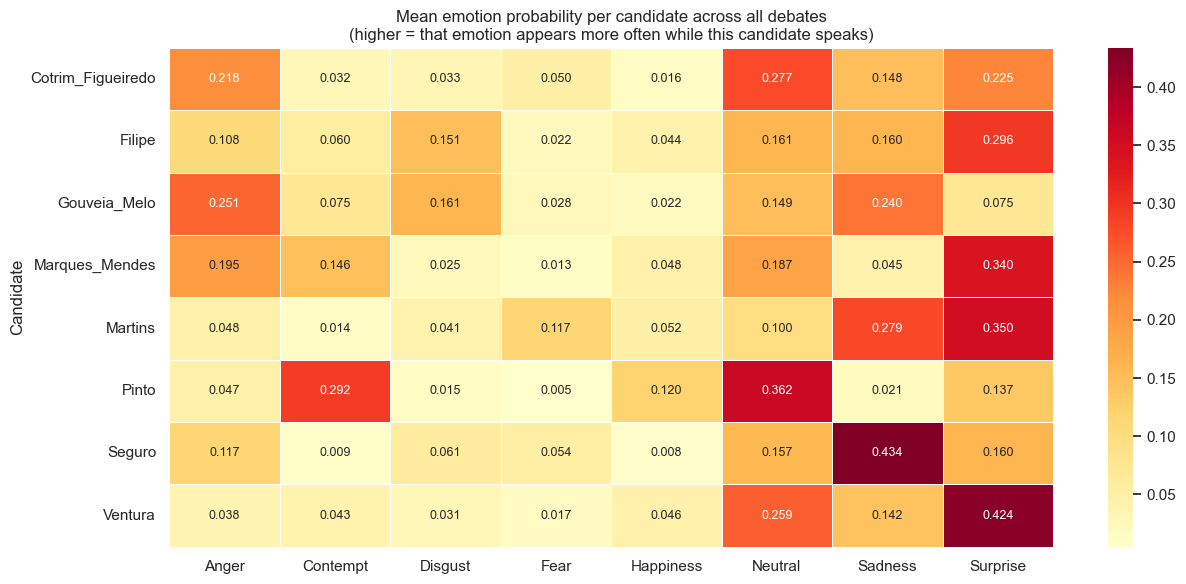

Dominant emotion per candidate:
final_name
Cotrim_Figueiredo     Neutral
Filipe               Surprise
Gouveia_Melo            Anger
Marques_Mendes       Surprise
Martins              Surprise
Pinto                 Neutral
Seguro                Sadness
Ventura              Surprise

Least common emotion per candidate:
final_name
Cotrim_Figueiredo    Happiness
Filipe                    Fear
Gouveia_Melo         Happiness
Marques_Mendes            Fear
Martins               Contempt
Pinto                     Fear
Seguro               Happiness
Ventura                   Fear


In [96]:
emotion_profile = seg_cands.groupby('final_name')[emotion_cols].mean()
# rename columns: prob_Anger -> Anger
emotion_profile.columns = [c.replace('prob_','') for c in emotion_profile.columns]
emotion_profile = emotion_profile.reindex(CANDIDATES)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(emotion_profile, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size':9})
ax.set_title('Mean emotion probability per candidate across all debates\n'
             '(higher = that emotion appears more often while this candidate speaks)', fontsize=12)
ax.set_ylabel('Candidate')
plt.tight_layout(); plt.show()

print('Dominant emotion per candidate:')
print(emotion_profile.idxmax(axis=1).to_string())
print()
print('Least common emotion per candidate:')
print(emotion_profile.idxmin(axis=1).to_string())


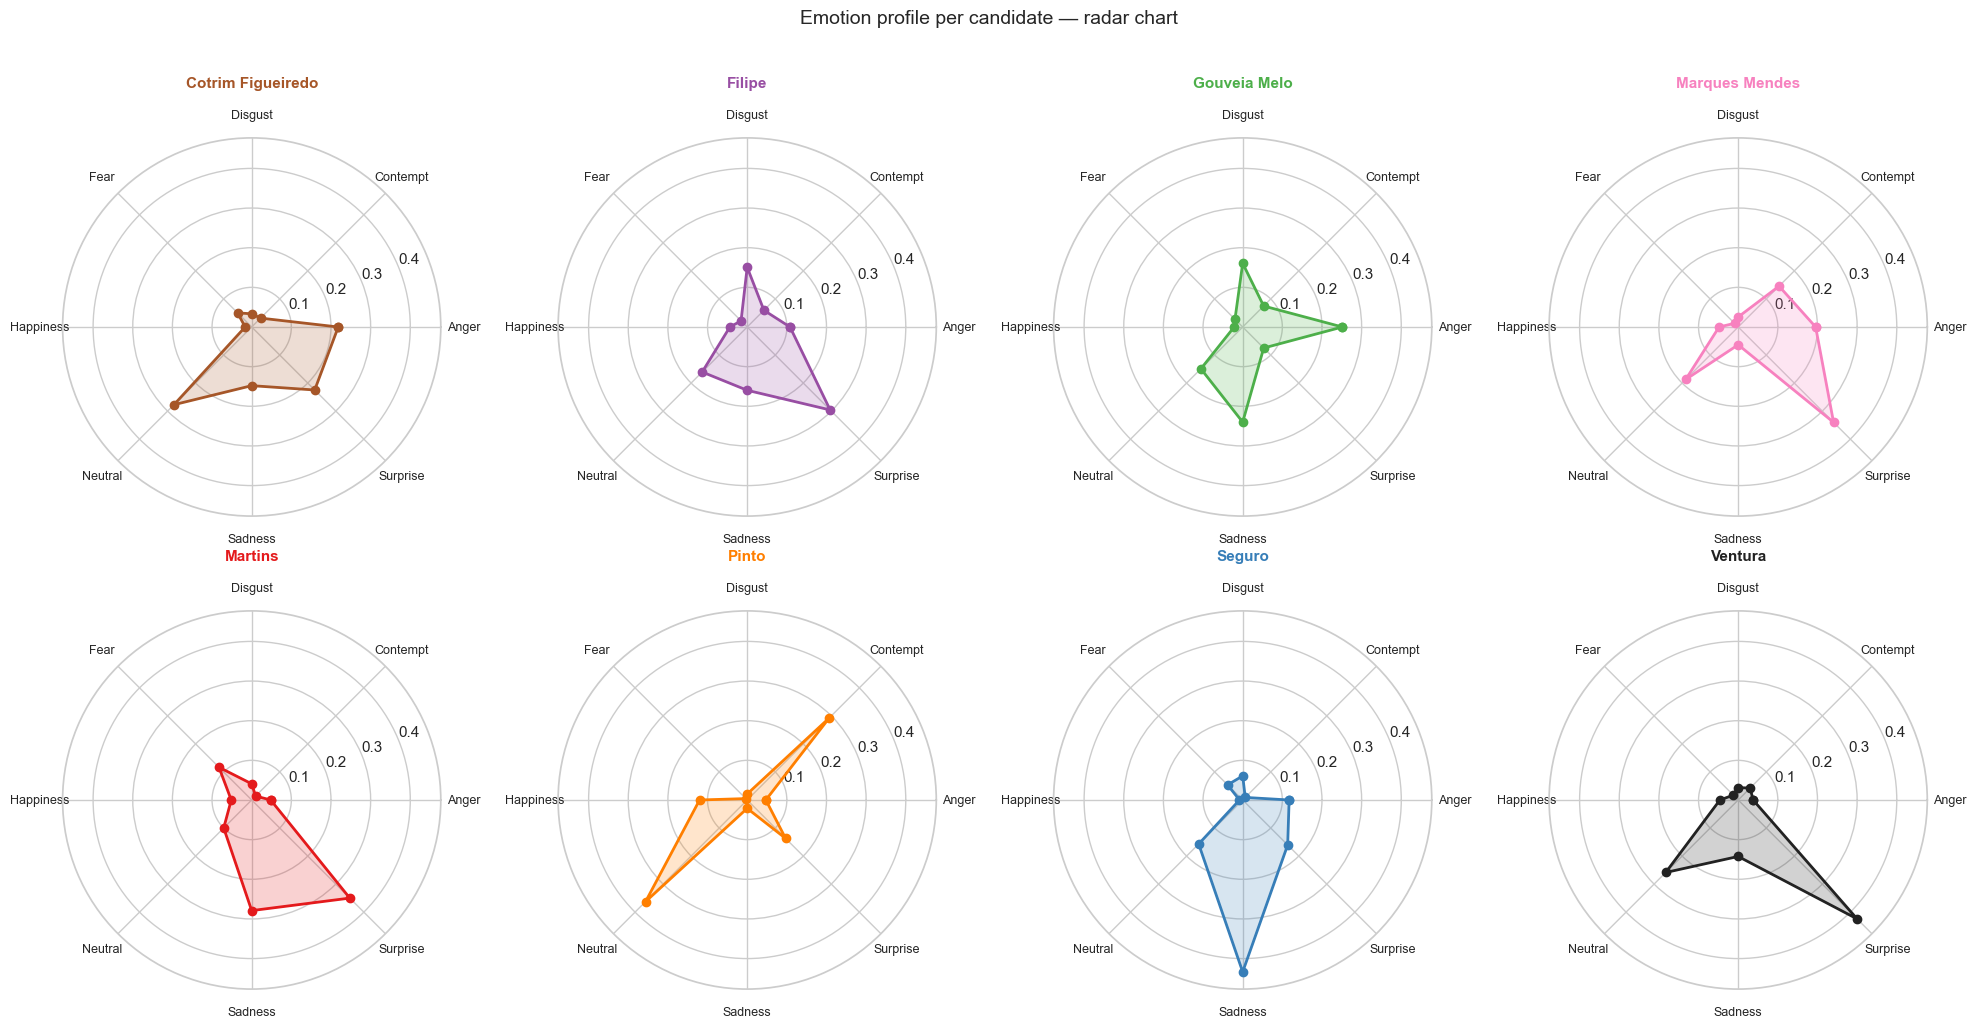

In [97]:
# Radar / spider chart of emotion profiles per candidate
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

emotions = [c.replace('prob_','') for c in emotion_cols]
N = len(emotions)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, axes = plt.subplots(2, 4, figsize=(20, 10), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

for ax, cand in zip(axes, CANDIDATES):
    if cand not in emotion_profile.index:
        ax.axis('off'); continue
    vals = list(emotion_profile.loc[cand].values) + [emotion_profile.loc[cand].values[0]]
    ax.plot(angles, vals, 'o-', lw=2, color=CAND_COLOR.get(cand,'grey'))
    ax.fill(angles, vals, alpha=0.2, color=CAND_COLOR.get(cand,'grey'))
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(emotions, fontsize=9)
    ax.set_title(cand.replace('_',' '), fontsize=11, pad=15,
                 color=CAND_COLOR.get(cand,'grey'), fontweight='bold')
    ax.set_ylim(0, emotion_profile.values.max()*1.1)

for ax in axes[len(CANDIDATES):]: ax.axis('off')
plt.suptitle('Emotion profile per candidate — radar chart', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## III.2 — Poll correlation

Can we predict a candidate's poll standing from their acoustic and emotional features?
We align each debate to the nearest poll in `polls_timeline.pkl` and compute
Spearman correlations between candidate-level features and their poll percentage.

In [98]:
polls = pd.read_pickle(os.path.join(FEATURES_DIR, 'polls_timeline.pkl'))

MONTHS_MAP = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
              'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}

def parse_date_str(s):
    parts = str(s).split('_')
    if len(parts)!=2: return None
    mon = MONTHS_MAP.get(parts[0])
    if not mon: return None
    yr = 2025 if mon>=9 else 2026
    return pd.Timestamp(yr, mon, int(parts[1]))

def parse_video_date(v):
    m = re.search(r'(January|February|March|April|May|June|July|August|'
                  r'September|October|November|December)_(\d+)', v)
    if not m: return None
    mon = MONTHS_MAP[m.group(1)]; day = int(m.group(2))
    yr = 2025 if mon>=10 else 2026
    return pd.Timestamp(yr, mon, day)

polls['poll_date'] = polls['date'].apply(parse_date_str)
polls = polls.dropna(subset=['poll_date']).sort_values('poll_date')

# Per-debate, per-candidate: mean acoustic + emotion features
seg_all['debate_date'] = seg_all['video'].apply(parse_video_date)
feat_cols = NON_REDUNDANT + [c for c in emotion_cols if c in seg_all.columns]

debate_cand_feats = (seg_all[seg_all['final_name'].isin(CANDIDATES)]
                     .groupby(['video','final_name','debate_date'])[feat_cols]
                     .mean().reset_index())

# For each debate, find the nearest poll
def nearest_poll_value(cand, debate_dt):
    if debate_dt is None or cand not in polls.columns: return np.nan
    diffs = (polls['poll_date'] - debate_dt).abs()
    idx = diffs.idxmin()
    return polls.loc[idx, cand]

debate_cand_feats['poll_pct'] = debate_cand_feats.apply(
    lambda r: nearest_poll_value(r['final_name'], r['debate_date']), axis=1)

print(f'Rows for correlation: {len(debate_cand_feats.dropna(subset=["poll_pct"]))}')
display(debate_cand_feats.head())

Rows for correlation: 52


,video,final_name,debate_date,meanF0Hz,stdevF0Hz,HNR,localJitter,localShimmer,speechrate,npause,...,fdisp,prob_Anger,prob_Contempt,prob_Disgust,prob_Fear,prob_Happiness,prob_Neutral,prob_Sadness,prob_Surprise,poll_pct
0,Cotrim_Figueiredo_vs_Filipe_November_30,Cotrim_Figueiredo,2025-11-30,140.322806,31.533575,9.870338,0.029310,0.109356,4.918151,2.285714,...,994.181883,0.127141,0.042358,0.018999,0.033547,0.017787,0.326699,0.179307,0.254162,3.0
1,Cotrim_Figueiredo_vs_Filipe_November_30,Filipe,2025-11-30,150.529880,34.855008,10.314818,0.030653,0.117108,4.950594,5.791667,...,1041.715975,0.069237,0.043713,0.141847,0.032420,0.029008,0.122979,0.169664,0.391132,1.0
2,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,Cotrim_Figueiredo,2025-11-20,131.361795,27.508577,11.362311,0.029486,0.114684,4.759202,2.600000,...,1036.987499,0.291228,0.017665,0.035290,0.087050,0.017761,0.284873,0.086669,0.179465,11.5
3,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,Gouveia_Melo,2025-11-20,130.523787,23.215677,11.455333,0.031790,0.110576,4.182833,1.920000,...,1111.251712,0.450008,0.054694,0.082958,0.033100,0.014683,0.185827,0.130162,0.048568,15.5
4,Cotrim_Figueiredo_vs_Ventura_December_19,Cotrim_Figueiredo,2025-12-19,157.335438,36.776128,11.014299,0.028426,0.108998,5.105090,1.382979,...,996.610236,0.263204,0.025230,0.049800,0.048500,0.013566,0.208351,0.126927,0.264423,8.0


Feature correlations with poll standing:


,rho,p,n
f2_mean,-0.512,0.000,52.0
npause,-0.420,0.002,52.0
prob_Happiness,-0.348,0.012,52.0
HNR,-0.320,0.021,52.0
prob_Anger,0.305,0.028,52.0
speechrate,-0.295,0.034,52.0
localJitter,0.232,0.098,52.0
prob_Sadness,0.231,0.099,52.0
meanF0Hz,-0.180,0.202,52.0
stdevF0Hz,0.171,0.226,52.0


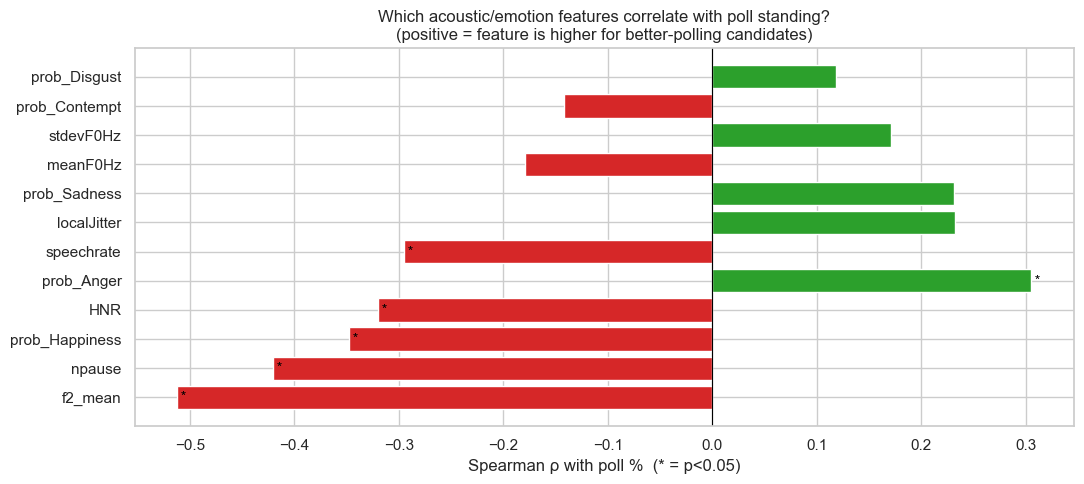

In [99]:
# Spearman correlation: acoustic/emotion features vs poll percentage
valid = debate_cand_feats.dropna(subset=['poll_pct'])
poll_corr = {}
for f in feat_cols:
    d = valid[[f,'poll_pct']].dropna()
    if len(d)<10: continue
    rho,p = spearmanr(d[f], d['poll_pct'])
    poll_corr[f] = {'rho':rho,'p':p,'n':len(d)}

poll_corr_df = (pd.DataFrame(poll_corr).T
                .sort_values('rho', key=abs, ascending=False))
print('Feature correlations with poll standing:')
display(poll_corr_df.round(3).head(15))

# Bar chart of top correlations
top = poll_corr_df.dropna().head(12)
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ca02c' if r>0 else '#d62728' for r in top['rho']]
bars = ax.barh(top.index, top['rho'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
for bar, (_, row) in zip(bars, top.iterrows()):
    sig = '*' if row['p']<0.05 else ''
    ax.text(row['rho'], bar.get_y()+bar.get_height()/2,
            f' {sig}', va='center', fontsize=10, color='black')
ax.set_xlabel('Spearman ρ with poll %  (* = p<0.05)')
ax.set_title('Which acoustic/emotion features correlate with poll standing?\n'
             '(positive = feature is higher for better-polling candidates)')
plt.tight_layout(); plt.show()

## III.3 — Candidate-opponent effect

Does a candidate **sound or look different** depending on who they are debating?
We build a candidate × opponent matrix for key features: if Candidate A's pitch
is systematically higher when debating Candidate B than C, that is an opponent effect.
This is only testable across multiple debates.

Candidate-opponent records: 48


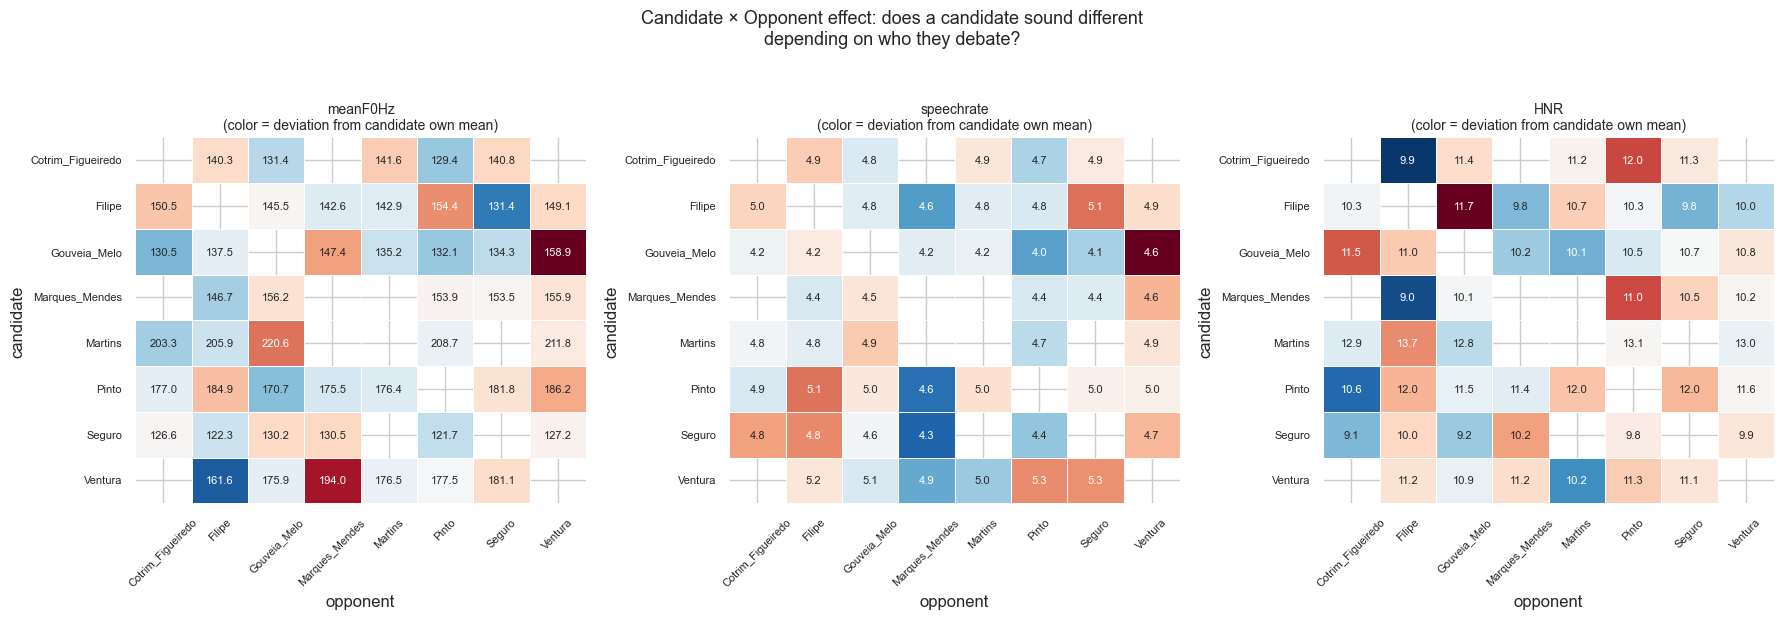

In [61]:
# Build candidate × opponent feature means
opp_rows = []
for v in debate_videos:
    cA,cB = extract_candidates(v)
    if cA is None: continue
    for cand,opp in [(cA,cB),(cB,cA)]:
        segs = seg_all[(seg_all['video']==v) & (seg_all['final_name']==cand)]
        if len(segs)==0: continue
        row = {'candidate':cand,'opponent':opp,'n_segs':len(segs)}
        row.update(segs[NON_REDUNDANT].mean().to_dict())
        if emotion_cols:
            row.update(segs[emotion_cols].mean().to_dict())
        opp_rows.append(row)

opp_df = pd.DataFrame(opp_rows)
print(f'Candidate-opponent records: {len(opp_df)}')

# For each candidate: show how pitch and speechrate vary by opponent
SHOW_FEATS = ['meanF0Hz','speechrate','HNR']
fig, axes = plt.subplots(1, len(SHOW_FEATS), figsize=(18, 6))
for ax, feat in zip(axes, SHOW_FEATS):
      pivot = opp_df.pivot_table(index='candidate', columns='opponent', values=feat, aggfunc='mean')
      pivot = pivot.reindex(index=CANDIDATES, columns=CANDIDATES)

      # center each row by that candidate's own mean across their 7 debates
      row_centered = pivot.sub(pivot.mean(axis=1), axis=0)

      sns.heatmap(row_centered.astype(float),
                  annot=pivot.round(1).astype(float),   # show real values
                  fmt='.1f', cmap='RdBu_r',
                  center=0, ax=ax, linewidths=0.4, cbar=False,
                  annot_kws={'size': 8})
      ax.set_title(f'{feat}\n(color = deviation from candidate own mean)', fontsize=10)
      ax.tick_params(axis='x', rotation=45, labelsize=8)
      ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.suptitle('Candidate × Opponent effect: does a candidate sound different\n'
             'depending on who they debate?', fontsize=13, y=1.03)
plt.tight_layout(); plt.show()